In [1]:
## Import the necessary library for reading the file.
import os
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
from dask.distributed import Client
import dask.array as da
#import h5netcdf
#import netCDF4

In [ ]:
## Import module load 
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from typing import Union, List, Tuple

## Function to subset any given geofabric upstream of list of outlets
def subset_upstream_basins_shapefile(
    input_basin_path: str,
    input_river_path: str,
    start_ranks: Union[int, float, List[int], np.ndarray, pd.Series],
    rank_id_col: str,
    next_id_col: str,
    unit_area_col: str,
    upstream_area_col: str,
    output_basin_path: str,
    output_river_path: str,
    include_downstream: bool = False
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:  
    """
    Subset upstream basins from a GeoFabric based on outlet rank IDs.
    Optionally includes the immediate downstream basin(s) and updates their upstream area.

    Parameters:
        input_basin_path (str): Path to input basin shapefile.
        input_river_path (str): Path to input river shapefile.
        start_ranks: Outlet rank(s) to start upstream search (int, list, np.ndarray, or Series).
        rank_id_col (str): Column name for basin ID.
        next_id_col (str): Column name for downstream ID.
        unit_area_col (str): Area of the subbasin.
        upstream_area_col (str): Column to update with total upstream area.
        output_basin_path (str): Path to save output basin shapefile.
        output_river_path (str): Path to save output river shapefile.
        include_downstream (bool): Include immediate downstream basin(s) and update area.

    Returns:
        Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]: Subsetted basin and river GeoDataFrames.
    """
    gdf_basin = gpd.read_file(input_basin_path).copy()
    gdf_river = gpd.read_file(input_river_path).copy()

    # Merge operation to join attribute table from input_river into input_basin
    missing_cols = [col for col in gdf_river.columns if col not in gdf_basin.columns[1:]]
    gdf_basin = gdf_basin.merge(gdf_river[missing_cols].copy(), on='COMID', how='left') 

    # Validate required columns
    required_cols = [rank_id_col, next_id_col, upstream_area_col, unit_area_col]    
    missing_cols = [col for col in required_cols if col not in gdf_basin.columns]
    if missing_cols:
        raise ValueError(f"Missing required column(s) in basin shapefile: {', '.join(missing_cols)}")

    # Normalize start_ranks
    if isinstance(start_ranks, (int, float)):
        start_ranks = [int(start_ranks)]
    elif isinstance(start_ranks, (np.ndarray, pd.Series)):
        start_ranks = start_ranks.astype(int).tolist()
    elif isinstance(start_ranks, list):
        start_ranks = list(map(int, start_ranks))
    else:
        raise TypeError(f"Unsupported type for start_ranks: {type(start_ranks).__name__}")

    # Build maps
    downstream_map = gdf_basin.set_index(rank_id_col)[next_id_col].to_dict()
    upstream_map = (
        gdf_basin[[rank_id_col, next_id_col]]
        .dropna()
        .groupby(next_id_col)[rank_id_col]
        .apply(list)
        .to_dict()
    )

    # Determine true outlet basins
    start_set = set(start_ranks)
    nested_outlets = {r for r in start_set if downstream_map.get(r) in start_set}
    true_outlets = start_set - nested_outlets
    if not true_outlets:
        raise ValueError("No valid outlets found (possibly circular or nested relationships).")

    # Traverse upstream
    visited = set()
    stack = list(true_outlets)
    while stack:
        current = stack.pop()
        if current not in visited:
            visited.add(current)
            stack.extend(upstream_map.get(current, []))

    downstream_ids = []

    if include_downstream:
        # Add immediate downstream(s) if not already included
        downstream_ids = [
            downstream_map[o] for o in true_outlets
            if downstream_map.get(o) not in visited and downstream_map.get(o) is not None
        ]
        visited.update(downstream_ids)

        # Update next_id_col to mark outlet point
        gdf_basin.loc[gdf_basin[rank_id_col].isin(downstream_ids), next_id_col] = -9999

        # Update upstream area of downstream basins
        for outlet in true_outlets:
            downstream_id = downstream_map.get(outlet)
            if downstream_id in downstream_ids:
                try:
                    outlet_area = gdf_basin.loc[gdf_basin[rank_id_col] == outlet, upstream_area_col].values[0]
                    unit_area = gdf_basin.loc[gdf_basin[rank_id_col] == downstream_id, unit_area_col].values[0]
                    gdf_basin.loc[gdf_basin[rank_id_col] == downstream_id, upstream_area_col] = outlet_area + unit_area
                except IndexError:
                    continue
    else:
        gdf_basin.loc[gdf_basin[rank_id_col].isin(true_outlets), next_id_col] = -9999

    # Subset basin and river layers
    gdf_basin = gdf_basin[gdf_basin[rank_id_col].isin(visited)].copy()
    gdf_river = gdf_river[gdf_river[rank_id_col].isin(gdf_basin[rank_id_col])].copy()

    # Save to files
    os.makedirs(os.path.dirname(output_basin_path), exist_ok=True)
    gdf_basin.to_file(output_basin_path, driver='ESRI Shapefile')
    print(f"✅ Saved basin subset to: {output_basin_path}")

    os.makedirs(os.path.dirname(output_river_path), exist_ok=True)
    gdf_river.to_file(output_river_path, driver='ESRI Shapefile')
    print(f"✅ Saved river subset to: {output_river_path}")

    return gdf_basin, gdf_river
    
#######################################################################################################
## Function to subset input drainage database netcdf file for the study of interest
import xarray as xr
import numpy as np
import geopandas as gpd
import pandas as pd
import netCDF4 as nc

## Subset functions
def subset_netcdf_ddb(
    input_basin_path,
    input_ddb_nc_path,
    output_ddb_nc_path
):
    """
    Subset and rebuild DDB network while preserving
    proper basin connectivity.

    Improvements:
    -------------
    1. Preserves independent outlets
    2. Prevents artificial global outlet creation
    3. Safely handles missing downstream basins
    4. Preserves original topology as much as possible
    """

    # -------------------------------------------------
    # Load inputs
    # -------------------------------------------------
    print("Loading inputs...")

    gdf = gpd.read_file(input_basin_path)
    ds = xr.open_dataset(input_ddb_nc_path)

    rank_id = ds["Rank"].values.astype(int)
    next_id = ds["Next"].values.astype(int)
    comid = ds["subbasin"].values.astype(int)

    # -------------------------------------------------
    # Merge Rank / Next into GeoDataFrame
    # -------------------------------------------------
    print("Merging Rank/Next information...")

    df = pd.DataFrame({
        "COMID": comid,
        "Rank": rank_id,
        "Next": next_id
    })

    gdf = (
        gdf
        .drop(columns=["Rank", "Next"], errors="ignore")
        .merge(df, on="COMID", how="left")
    )

    # -------------------------------------------------
    # Clean attributes
    # -------------------------------------------------
    print("Cleaning topology fields...")

    # Force outlets to Next = 0
    gdf.loc[
        gdf["NextDownID"].isin([0, -9999, -9999.0]),
        "Next"
    ] = 0

    gdf["Rank_int"] = gdf["Rank"].astype("Int64")
    gdf["Next_int"] = gdf["Next"].fillna(0).astype(int)

    # Remove rows without Rank
    gdf = gdf[gdf["Rank_int"].notna()].copy()

    # -------------------------------------------------
    # Identify outlets
    # -------------------------------------------------
    print("Identifying outlets...")

    is_outlet = gdf["NextDownID"].isin([0, -9999, -9999.0])

    outlet = (
        gdf.loc[is_outlet, "Rank_int"]
        .astype(int)
        .values
    )

    non_outlet = (
        gdf.loc[~is_outlet, "Rank_int"]
        .astype(int)
        .values
    )

    # -------------------------------------------------
    # Reorder network
    # -------------------------------------------------
    print("Reordering network...")

    reordered = np.concatenate([
        np.sort(non_outlet),
        np.sort(outlet)
    ])

    # Remove duplicates
    reordered = np.unique(reordered)
#    _, first = np.unique(reordered, return_index=True)
#    reordered = reordered[np.sort(first)]
    
    # -------------------------------------------------
    # Build lookup index
    # -------------------------------------------------
    rank_to_idx = {
        r: i for i, r in enumerate(rank_id)
    }

    indices = [
        rank_to_idx[r]
        for r in reordered
        if r in rank_to_idx
    ]

    # -------------------------------------------------
    # Create sequential Rank mapping
    # -------------------------------------------------
    print("Creating new Rank mapping...")

    rank_map = {
        old_rank: new_rank
        for new_rank, old_rank in enumerate(reordered, start=1)
    }

    gdf_sub = (
        gdf
        .set_index("Rank_int")
        .loc[reordered]
    )

    # -------------------------------------------------
    # Create new Rank
    # -------------------------------------------------
    new_rank = np.array(
        [rank_map[r] for r in reordered],
        dtype=np.int32
    )

    # -------------------------------------------------
    # Create new Next
    # -------------------------------------------------
    print("Rebuilding downstream connectivity...")

    new_next = []

    for old_rank, old_next in zip(
        reordered,
        gdf_sub["Next_int"].values
    ):

        # Preserve outlets
        if old_next in [0, -9999]:
            new_next.append(0)
            continue

        # Valid downstream basin
        if old_next in rank_map:
            new_next.append(rank_map[old_next])

        else:
            # Missing downstream basin after subset
            # Convert to outlet instead of forcing connectivity
            print(
                f"WARNING: Basin {old_rank} downstream "
                f"{old_next} missing after subset. "
                f"Setting as outlet."
            )
            new_next.append(0)

    new_next = np.array(new_next, dtype=np.int32)

    # -------------------------------------------------
    # Topology validation
    # -------------------------------------------------
    print("Validating topology...")

    # Self-loops
    self_loops = new_rank[new_rank == new_next]

    if len(self_loops) > 0:
        print("WARNING: Self-loops detected:")
        print(self_loops)

    # Invalid downstream references
    invalid = new_next[
        (new_next != 0) &
        (~np.isin(new_next, new_rank))
    ]

    if len(invalid) > 0:
        print("WARNING: Invalid downstream references detected")

    # -------------------------------------------------
    # WRITE NETCDF
    # -------------------------------------------------
    print("Writing NetCDF...")

    with nc.Dataset(output_ddb_nc_path, "w") as dst:

        # -------------------------------------------------
        # Dimensions
        # -------------------------------------------------
        for dim, size in ds.sizes.items():

            if dim == "subbasin":
                dst.createDimension(dim, len(new_rank))
            else:
                dst.createDimension(dim, size)

        # -------------------------------------------------
        # Global attributes
        # -------------------------------------------------
        for attr in ds.attrs:
            setattr(dst, attr, ds.attrs[attr])

        # -------------------------------------------------
        # Copy variables except modified ones
        # -------------------------------------------------
        skip = {
            "Rank",
            "Next",
            "Rank_old",
            "Next_old"
        }

        for name, var in ds.variables.items():

            if name in skip:
                continue

            fill = var.encoding.get("_FillValue", None)

            out = dst.createVariable(
                name,
                var.dtype,
                var.dims,
                fill_value=fill
            )

            data = var.values

            # Subset along subbasin dimension
            if "subbasin" in var.dims:

                axis = var.dims.index("subbasin")

                data = np.take(
                    data,
                    indices,
                    axis=axis
                )

            out[:] = data

            # Copy attributes
            for a, v in var.attrs.items():
                setattr(out, a, v)

            # Ensure coordinates attribute
            if "coordinates" not in var.attrs and var.ndim > 0:
                out.coordinates = "lon lat time"

        # -------------------------------------------------
        # Write Rank and Next
        # -------------------------------------------------
        for name, values in [
            ("Rank", new_rank),
            ("Next", new_next)
        ]:

            var = dst.createVariable(
                name,
                "i4",
                ("subbasin",),
                fill_value=-1
            )

            var[:] = values

            src = ds[name]

            for a, v in src.attrs.items():
                setattr(var, a, v)

            # Ensure critical metadata
            var.coordinates = src.attrs.get(
                "coordinates",
                "lon lat time"
            )

            var.grid_mapping = src.attrs.get(
                "grid_mapping",
                "crs"
            )

            var.standard_name = src.attrs.get(
                "standard_name",
                name
            )

            var.long_name = src.attrs.get(
                "long_name",
                name
            )

        # -------------------------------------------------
        # Rank_old
        # -------------------------------------------------
        ro = dst.createVariable(
            "Rank_old",
            "i4",
            ("subbasin",),
            fill_value=-1
        )

        ro[:] = reordered.astype(np.int32)

        ro.standard_name = "Rank_old"
        ro.long_name = "Original Rank"
        ro.grid_mapping = "crs"
        ro.coordinates = "lon lat time"

        # -------------------------------------------------
        # Next_old
        # -------------------------------------------------
        no = dst.createVariable(
            "Next_old",
            "i4",
            ("subbasin",),
            fill_value=-1
        )

        no[:] = gdf_sub["Next_int"].values.astype(np.int32)

        no.standard_name = "Next_old"
        no.long_name = "Original Next downstream ID"
        no.grid_mapping = "crs"
        no.coordinates = "lon lat time"
    # -------------------------------------------------
    # Done
    # -------------------------------------------------
    print(f"✅ Done: {output_ddb_nc_path}")


## Function to adjust the Next of all outlet other than the one with 
# the maximum Rank to flow into the Outlet with the maximum Rank
import xarray as xr

def move_one_subbasin_outlets_into_maxrank_outlet(
    input_ddb_nc,
    output_ddb_nc
):
    # Open the dataset in read/write mode
    with xr.open_dataset(input_ddb_nc) as ds_ddb:
        # Load the variables into memory if necessary
        ds_ddb.load()
        # Compute the maximum rank
        max_rank = ds_ddb['Rank'].max()
        # Create a mask where Next == 0 and Rank != max_rank
        mask = (ds_ddb['Next'] == 0) & (ds_ddb['Rank'] != max_rank)
        # Update 'Next' where the mask is True
        ds_ddb['Next'] = ds_ddb['Next'].where(~mask, other=max_rank)
        # Save the updated dataset to a new file or overwrite the existing one
        ds_ddb.to_netcdf(output_ddb_nc)  # or input_ddb_nc_path to overwrite
    return 

# Application of the domain specific script to add a pad-outlet to the existing MESH_drainage_database.nc files
#input_ddb_nc = os.path.join(directory1, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
#output_ddb_nc = os.path.join(directory1, "pad_MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
#move_one_subbasin_outlets_into_maxrank_outlet(input_ddb_nc, output_ddb_nc)

###################################################################################################
## Final Function to subset input forcing and parameters netcdf file for the study of interest


#######################################################################################################

# Copy the required MESH input file
def edit_TotalNumOfGridsSubbasins_value(input_file_path, output_file_path, new_value):
        with open(input_file_path, 'r', encoding='utf-8') as src:
            lines = src.readlines()
            line = lines[3]
            # Preserve leading spaces/tabs
            leading_ws = line[:len(line) - len(line.lstrip())]
            # Split while preserving spacing logic
            tokens = line.strip().split()
            tokens[7] = str(new_value)
            # Rebuild the line with original indentation
            lines[3] = leading_ws + '   '.join(tokens) + '\n'
        with open(output_file_path, 'w', encoding='utf-8') as dest:
            dest.writelines(lines)


#######################################################################################################
# Function to extract the streamflow file for a given Stations ID
def extract_columns_with_header(input_file, column_names, output_file=None):
    with open(input_file, 'r') as f:
        lines = f.readlines()

    # Step 1: Extract full column list
    full_column_names = []
    for line in lines:
        if line.strip().startswith(':ColumnName'):
            full_column_names = line.strip().split()[1:]
            break

    if not full_column_names:
        raise ValueError("No ':ColumnName' line found.")

    # Map target names to indices
    col_indices = []
    for name in column_names:
        if name not in full_column_names:
            raise ValueError(f"Column '{name}' not found.")
        col_indices.append(full_column_names.index(name))

    # Step 2: Extract and reformat metadata
    in_colmeta = False
    metadata_dict = {}
    meta_order = []  # Preserve key order
    for line in lines:
        stripped = line.strip()
        if stripped == ':ColumnMetaData':
            in_colmeta = True
            continue
        elif stripped == ':EndColumnMetaData':
            in_colmeta = False
            continue
        elif in_colmeta:
            parts = line.strip().split()
            if not parts:
                continue
            key = parts[0]
            values = parts[1:]
            metadata_dict[key] = values
            meta_order.append(key)

    # Step 3: Extract header (lines before :ColumnMetaData)
    header_lines = []
    for line in lines:
        if line.strip() == ':ColumnMetaData':
            break
        header_lines.append(line)

    # Step 4: Extract data lines
    data_started = False
    data_lines = []
    for line in lines:
        if data_started:
            if line.strip() == '':
                continue
            parts = line.strip().split()
            selected = [parts[i] if i < len(parts) else '' for i in col_indices]
            data_lines.append(''.join(f"{val:>13}" for val in selected) + '\n')
        elif line.strip() == ':endHeader':
            data_started = True

    # Step 5: Reconstruct metadata block with formatting
    col_spacing = 13  # Same as original fixed width
    formatted_meta = []
    formatted_meta.append(':ColumnMetaData\n')
    for key in meta_order:
        values = metadata_dict.get(key, [])
        selected = [values[i] if i < len(values) else '' for i in col_indices]
        formatted_line = f"   {key:<20}" + ''.join(f"{val:>{col_spacing}}" for val in selected) + '\n'
        formatted_meta.append(formatted_line)
    formatted_meta.append(':EndColumnMetaData\n')

    # Step 6: Write output in correct order
    if output_file:
        with open(output_file, 'w') as out:
            for line in header_lines:
                out.write(line)
            for line in formatted_meta:
                out.write(line)
            out.write(':endHeader\n')
            for line in data_lines:
                out.write(line)
        print(f"✅ Extracted columns {column_names} to '{output_file}'")
    else:
        for line in header_lines:
            print(line, end='')
        for line in formatted_meta:
            print(line, end='')
        print(':endHeader')
        for line in data_lines:
            print(line, end='')

### === Example usage ===
#extract_columns_with_header(
#    input_streamflow_tb0,
#    ['10UH001'],  # multiple columns to extract
#    output_streamflow_tb0
#)


# Function to update the coordinate of a streamflow file in cases where the highest Rank subbasin has a guage
import re

def update_column_coordinates(file_path, column_name, new_x, new_y, output_path=None):
    with open(file_path, "r") as f:
        lines = f.readlines()

    col_index = None

    # Find column index
    for line in lines:
        if line.strip().startswith(":ColumnName"):
            column_names = line.split()[1:]
            if column_name not in column_names:
                raise ValueError(f"Column '{column_name}' not found.")
            col_index = column_names.index(column_name)
            break

    if col_index is None:
        raise ValueError("ColumnName line not found.")

    def replace_nth_number(line, index, new_value):
        matches = list(re.finditer(r"-?\d+\.\d+", line))
        if index >= len(matches):
            return line  # safety

        m = matches[index]
        start, end = m.span()

        # preserve original width
        old_text = line[start:end]
        width = len(old_text)

        new_text = f"{new_value:.5f}".rjust(width)

        return line[:start] + new_text + line[end:]

    # Update lines
    for i, line in enumerate(lines):
        stripped = line.strip()

        if stripped.startswith(":ColumnLocationX"):
            lines[i] = replace_nth_number(line, col_index, new_x)

        elif stripped.startswith(":ColumnLocationY"):
            lines[i] = replace_nth_number(line, col_index, new_y)

    if output_path is None:
        output_path = file_path

    with open(output_path, "w") as f:
        f.writelines(lines)

# Example usage
# update_column_coordinates(
#    file_path="input.tb0",
#    column_name="10UH001",
#    new_x=-70.12345,
#    new_y=65.98765,
#    output_path="output.tb0"
#)

In [3]:
# Version 1## Import module load 
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from typing import Union, List, Tuple

## Function to subset any given geofabric upstream of list of outlets
def subset_upstream_basins_shapefile(
    input_basin_path: str,
    input_river_path: str,
    start_ranks: Union[int, float, List[int], np.ndarray, pd.Series],
    rank_id_col: str,
    next_id_col: str,
    unit_area_col: str,
    upstream_area_col: str,
    output_basin_path: str,
    output_river_path: str,
    include_downstream: bool = False
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]:  
    """
    Subset upstream basins from a GeoFabric based on outlet rank IDs.
    Optionally includes the immediate downstream basin(s) and updates their upstream area.

    Parameters:
        input_basin_path (str): Path to input basin shapefile.
        input_river_path (str): Path to input river shapefile.
        start_ranks: Outlet rank(s) to start upstream search (int, list, np.ndarray, or Series).
        rank_id_col (str): Column name for basin ID.
        next_id_col (str): Column name for downstream ID.
        unit_area_col (str): Area of the subbasin.
        upstream_area_col (str): Column to update with total upstream area.
        output_basin_path (str): Path to save output basin shapefile.
        output_river_path (str): Path to save output river shapefile.
        include_downstream (bool): Include immediate downstream basin(s) and update area.

    Returns:
        Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame]: Subsetted basin and river GeoDataFrames.
    """
    gdf_basin = gpd.read_file(input_basin_path).copy()
    gdf_river = gpd.read_file(input_river_path).copy()

    # Merge operation to join attribute table from input_river into input_basin
    missing_cols = [col for col in gdf_river.columns if col not in gdf_basin.columns[1:]]
    gdf_basin = gdf_basin.merge(gdf_river[missing_cols].copy(), on='COMID', how='left') 

    # Validate required columns
    required_cols = [rank_id_col, next_id_col, upstream_area_col, unit_area_col]    
    missing_cols = [col for col in required_cols if col not in gdf_basin.columns]
    if missing_cols:
        raise ValueError(f"Missing required column(s) in basin shapefile: {', '.join(missing_cols)}")

    # Normalize start_ranks
    if isinstance(start_ranks, (int, float)):
        start_ranks = [int(start_ranks)]
    elif isinstance(start_ranks, (np.ndarray, pd.Series)):
        start_ranks = start_ranks.astype(int).tolist()
    elif isinstance(start_ranks, list):
        start_ranks = list(map(int, start_ranks))
    else:
        raise TypeError(f"Unsupported type for start_ranks: {type(start_ranks).__name__}")

    # Build maps
    downstream_map = gdf_basin.set_index(rank_id_col)[next_id_col].to_dict()
    upstream_map = (
        gdf_basin[[rank_id_col, next_id_col]]
        .dropna()
        .groupby(next_id_col)[rank_id_col]
        .apply(list)
        .to_dict()
    )

    # Determine true outlet basins
    start_set = set(start_ranks)
    nested_outlets = {r for r in start_set if downstream_map.get(r) in start_set}
    true_outlets = start_set - nested_outlets
    if not true_outlets:
        raise ValueError("No valid outlets found (possibly circular or nested relationships).")

    # Traverse upstream
    visited = set()
    stack = list(true_outlets)
    while stack:
        current = stack.pop()
        if current not in visited:
            visited.add(current)
            stack.extend(upstream_map.get(current, []))

    downstream_ids = []

    if include_downstream:
        # Add immediate downstream(s) if not already included
        downstream_ids = [
            downstream_map[o] for o in true_outlets
            if downstream_map.get(o) not in visited and downstream_map.get(o) is not None
        ]
        visited.update(downstream_ids)

        # Update next_id_col to mark outlet point
        gdf_basin.loc[gdf_basin[rank_id_col].isin(downstream_ids), next_id_col] = -9999

        # Update upstream area of downstream basins
        for outlet in true_outlets:
            downstream_id = downstream_map.get(outlet)
            if downstream_id in downstream_ids:
                try:
                    outlet_area = gdf_basin.loc[gdf_basin[rank_id_col] == outlet, upstream_area_col].values[0]
                    unit_area = gdf_basin.loc[gdf_basin[rank_id_col] == downstream_id, unit_area_col].values[0]
                    gdf_basin.loc[gdf_basin[rank_id_col] == downstream_id, upstream_area_col] = outlet_area + unit_area
                except IndexError:
                    continue
    else:
        gdf_basin.loc[gdf_basin[rank_id_col].isin(true_outlets), next_id_col] = -9999

    # Subset basin and river layers
    gdf_basin = gdf_basin[gdf_basin[rank_id_col].isin(visited)].copy()
    gdf_river = gdf_river[gdf_river[rank_id_col].isin(gdf_basin[rank_id_col])].copy()

    # Save to files
    os.makedirs(os.path.dirname(output_basin_path), exist_ok=True)
    gdf_basin.to_file(output_basin_path, driver='ESRI Shapefile')
    print(f"✅ Saved basin subset to: {output_basin_path}")

    os.makedirs(os.path.dirname(output_river_path), exist_ok=True)
    gdf_river.to_file(output_river_path, driver='ESRI Shapefile')
    print(f"✅ Saved river subset to: {output_river_path}")

    return gdf_basin, gdf_river
    

## Function to subset input drainage database netcdf file for the study of interest
import xarray as xr
import numpy as np
import geopandas as gpd
import pandas as pd
import netCDF4 as nc


def subset_netcdf_ddb(input_basin_path, input_ddb_nc_path, output_ddb_nc_path):
    """
    Subset and rebuild DDB network while preserving topology.
    """

    print("Loading inputs...")

    gdf = gpd.read_file(input_basin_path)
    ds = xr.open_dataset(input_ddb_nc_path)

    rank_id = ds["Rank"].values.astype(int)
    next_id = ds["Next"].values.astype(int)
    comid = ds["subbasin"].values.astype(int)

    # -------------------------------------------------
    # Merge topology info
    # -------------------------------------------------
    gdf = (
        gdf.drop(columns=["Rank", "Next"], errors="ignore")
        .merge(
            pd.DataFrame({
                "COMID": comid,
                "Rank": rank_id,
                "Next": next_id
            }),
            on="COMID",
            how="left"
        )
    )

    # -------------------------------------------------
    # Clean topology fields
    # -------------------------------------------------
    outlet_mask = gdf["NextDownID"].isin([0, -9999, -9999.0])

    gdf.loc[outlet_mask, "Next"] = 0
    gdf["Rank_int"] = gdf["Rank"].astype("Int64")
    gdf["Next_int"] = gdf["Next"].fillna(0).astype(int)

    gdf = gdf[gdf["Rank_int"].notna()].copy()

    # -------------------------------------------------
    # Reorder network
    # -------------------------------------------------
    reordered = np.concatenate([
        np.sort(gdf.loc[~outlet_mask, "Rank_int"].astype(int)),
        np.sort(gdf.loc[outlet_mask, "Rank_int"].astype(int))
    ])

    reordered = reordered[np.sort(np.unique(reordered, return_index=True)[1])]

    rank_to_idx = {r: i for i, r in enumerate(rank_id)}
    indices = [rank_to_idx[r] for r in reordered if r in rank_to_idx]

    rank_map = {r: i for i, r in enumerate(reordered, start=1)}

    gdf_sub = gdf.set_index("Rank_int").loc[reordered]

    # -------------------------------------------------
    # Build new Rank / Next
    # -------------------------------------------------
    print("Rebuilding connectivity...")

    new_rank = np.arange(1, len(reordered) + 1, dtype=np.int32)

    new_next = np.array([
        0 if n in [0, -9999]
        else rank_map.get(n, 0)
        for n in gdf_sub["Next_int"].values
    ], dtype=np.int32)

    # -------------------------------------------------
    # Validation
    # -------------------------------------------------
    self_loops = new_rank[new_rank == new_next]

    if len(self_loops):
        print("WARNING: Self-loops detected:", self_loops)

    invalid = new_next[(new_next != 0) & (~np.isin(new_next, new_rank))]

    if len(invalid):
        print("WARNING: Invalid downstream references detected")

    # -------------------------------------------------
    # Write NetCDF
    # -------------------------------------------------
    print("Writing NetCDF...")

    with nc.Dataset(output_ddb_nc_path, "w") as dst:

        # Dimensions
        for dim, size in ds.sizes.items():
            dst.createDimension(dim, len(new_rank) if dim == "subbasin" else size)

        # Global attrs
        for attr, val in ds.attrs.items():
            setattr(dst, attr, val)

        skip = {"Rank", "Next", "Rank_old", "Next_old"}

        # Copy variables
        for name, var in ds.variables.items():

            if name in skip:
                continue

            out = dst.createVariable(
                name,
                var.dtype,
                var.dims,
                fill_value=var.encoding.get("_FillValue")
            )

            data = var.values

            if "subbasin" in var.dims:
                data = np.take(data, indices, axis=var.dims.index("subbasin"))

            out[:] = data

            for a, v in var.attrs.items():
                setattr(out, a, v)

            if "coordinates" not in var.attrs and var.ndim > 0:
                out.coordinates = "lon lat time"

        # Write Rank / Next / originals
        vars_to_write = {
            "Rank": new_rank,
            "Next": new_next,
            "Rank_old": reordered.astype(np.int32),
            "Next_old": gdf_sub["Next_int"].values.astype(np.int32)
        }

        meta = {
            "Rank_old": ("Rank_old", "Original Rank"),
            "Next_old": ("Next_old", "Original Next downstream ID")
        }

        for name, values in vars_to_write.items():

            var = dst.createVariable(name, "i4", ("subbasin",), fill_value=-1)
            var[:] = values

            src = ds[name] if name in ds.variables else None

            if src is not None:
                for a, v in src.attrs.items():
                    setattr(var, a, v)

            var.coordinates = getattr(var, "coordinates", "lon lat time")
            var.grid_mapping = getattr(var, "grid_mapping", "crs")
            var.standard_name = meta.get(name, (name,))[0]
            var.long_name = meta.get(name, (name, name))[1]

    print(f"✅ Done: {output_ddb_nc_path}")


## Function to Subset Climate/Parameter NetCDF File
## using Rank_old as ORIGINAL source-file indices + 1
import os
import numpy as np
import xarray as xr
from netCDF4 import Dataset

def subset_netcdf_climate_and_parameters(
    input_nc_path,
    input_ddb_path,
    output_nc_path,
    dim="subbasin",
    key="Rank_old",
    time_chunksize=100000,
):

    os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

    # -------------------------------------------------
    # 1. read index file (small, fast)
    # -------------------------------------------------
    mask = xr.open_dataset(input_ddb_path, decode_cf=False)
    idx = mask[key].values.astype(np.int64)
    idx = idx[idx > 0] - 1
    mask.close()

    # -------------------------------------------------
    # 2. open source
    # -------------------------------------------------
    ds = xr.open_dataset(
        input_nc_path,
        chunks={"time": time_chunksize},
        decode_cf=False,
        cache=False,
    )

    src = Dataset(input_nc_path, "r")
    dst = Dataset(output_nc_path, "w", format=src.file_format)

    # -------------------------------------------------
    # 3. global attributes (exact copy)
    # -------------------------------------------------
    dst.setncatts({k: src.getncattr(k) for k in src.ncattrs()})

    # -------------------------------------------------
    # 4. dimensions
    # -------------------------------------------------
    for name, dimobj in src.dimensions.items():
        if name == dim:
            dst.createDimension(name, len(idx))
        else:
            dst.createDimension(name, None if dimobj.isunlimited() else len(dimobj))

    # -------------------------------------------------
    # 5. variables
    # -------------------------------------------------
    for name, var in src.variables.items():

        fill = getattr(var, "_FillValue", None)

        out = dst.createVariable(
            name,
            var.dtype,
            var.dimensions,
            fill_value=fill,
        )

        # ---- copy attributes safely (NO _FillValue here)
        attrs = {
            k: var.getncattr(k)
            for k in var.ncattrs()
            if k != "_FillValue"
        }
        out.setncatts(attrs)

        # -------------------------------------------------
        # subset data
        # -------------------------------------------------
        if dim in var.dimensions:

            axis = var.dimensions.index(dim)

            slc = [slice(None)] * var.ndim
            slc[axis] = idx

            # fast read via xarray cache
            data = ds[name].values[tuple(slc)]

            # renumber coordinate variable
            if name == dim:
                data = np.arange(1, len(idx) + 1, dtype=var.dtype)

            out[:] = data

        else:
            out[:] = ds[name].values

    # -------------------------------------------------
    # 6. close
    # -------------------------------------------------
    src.close()
    dst.close()
    ds.close()

    print("DONE:", output_nc_path)


# Function to extract the streamflow file for a given Stations ID
def extract_columns_with_header(input_file, column_names, output_file=None):
    with open(input_file, 'r') as f:
        lines = f.readlines()

    # Step 1: Extract full column list
    full_column_names = []
    for line in lines:
        if line.strip().startswith(':ColumnName'):
            full_column_names = line.strip().split()[1:]
            break

    if not full_column_names:
        raise ValueError("No ':ColumnName' line found.")

    # Map target names to indices
    col_indices = []
    for name in column_names:
        if name not in full_column_names:
            raise ValueError(f"Column '{name}' not found.")
        col_indices.append(full_column_names.index(name))

    # Step 2: Extract and reformat metadata
    in_colmeta = False
    metadata_dict = {}
    meta_order = []  # Preserve key order
    for line in lines:
        stripped = line.strip()
        if stripped == ':ColumnMetaData':
            in_colmeta = True
            continue
        elif stripped == ':EndColumnMetaData':
            in_colmeta = False
            continue
        elif in_colmeta:
            parts = line.strip().split()
            if not parts:
                continue
            key = parts[0]
            values = parts[1:]
            metadata_dict[key] = values
            meta_order.append(key)

    # Step 3: Extract header (lines before :ColumnMetaData)
    header_lines = []
    for line in lines:
        if line.strip() == ':ColumnMetaData':
            break
        header_lines.append(line)

    # Step 4: Extract data lines
    data_started = False
    data_lines = []
    for line in lines:
        if data_started:
            if line.strip() == '':
                continue
            parts = line.strip().split()
            selected = [parts[i] if i < len(parts) else '' for i in col_indices]
            data_lines.append(''.join(f"{val:>13}" for val in selected) + '\n')
        elif line.strip() == ':endHeader':
            data_started = True

    # Step 5: Reconstruct metadata block with formatting
    col_spacing = 13  # Same as original fixed width
    formatted_meta = []
    formatted_meta.append(':ColumnMetaData\n')
    for key in meta_order:
        values = metadata_dict.get(key, [])
        selected = [values[i] if i < len(values) else '' for i in col_indices]
        formatted_line = f"   {key:<20}" + ''.join(f"{val:>{col_spacing}}" for val in selected) + '\n'
        formatted_meta.append(formatted_line)
    formatted_meta.append(':EndColumnMetaData\n')

    # Step 6: Write output in correct order
    if output_file:
        with open(output_file, 'w') as out:
            for line in header_lines:
                out.write(line)
            for line in formatted_meta:
                out.write(line)
            out.write(':endHeader\n')
            for line in data_lines:
                out.write(line)
        print(f"✅ Extracted columns {column_names} to '{output_file}'")
    else:
        for line in header_lines:
            print(line, end='')
        for line in formatted_meta:
            print(line, end='')
        print(':endHeader')
        for line in data_lines:
            print(line, end='')

### === Example usage ===
#extract_columns_with_header(
#    input_streamflow_tb0,
#    ['10UH001'],  # multiple columns to extract
#    output_streamflow_tb0
#)

In [2]:
# Subset the group calibration from the Camels-spat basin domain setup 
# Define paths and directories
geofabric_path = '/scratch/zelalem/CanTrans-models/Calibration/Iteration_3.01/geofabric'
input_path = '/scratch/zelalem/CanTrans-models/Calibration/Iteration_3.01'
output_path = '/scratch/zelalem/CanTrans-models/Calibration/AllCalibration'

# Path to input shapefiles
input_stations = os.path.join(geofabric_path, "cantrans_camels_spat_all_station_locations.shp")
input_basin = os.path.join(geofabric_path, "sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
input_river = os.path.join(geofabric_path, "sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to input netcdf file
input_ddb_nc0 = os.path.join(input_path, "MESH_drainage_database_org_slope_length_fix.nc")
input_ddb_nc1 = os.path.join(input_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
input_ddb_nc2 = os.path.join(input_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
input_parameters_nc = os.path.join(input_path, "MESH_parameters_SoilGrid_CamelsSpatModel.nc")
input_forcing_nc = os.path.join(input_path, "MESH_forcing_camels_casr3p2_1979_2024.nc")
input_class_ini = os.path.join(input_path, "MESH_parameters_CLASS.ini")
input_streamflow_tb0 = os.path.join(input_path, "MESH_input_streamflow.tb0")

### Path to the output files
output_basin = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
output_river = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to output netcdf file
output_ddb_nc0 = os.path.join(output_path, "MESH_drainage_database_org_slope_length_fix.nc")
output_ddb_nc1 = os.path.join(output_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
output_ddb_nc2 = os.path.join(output_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
output_parameters_nc = os.path.join(output_path, "MESH_parameters.nc")
output_forcing_nc = os.path.join(output_path, "MESH_forcing_cal_camels_casr3p2_1979_2024.nc")
output_class_ini = os.path.join(output_path, "MESH_parameters_CLASS.ini")
output_streamflow_tb0 = os.path.join(output_path, "MESH_input_streamflow.tb0")

# CAMELS-SPAT stations
gdf_points = gpd.read_file(input_stations, engine="pyogrio")
gdf_points = gdf_points.dropna(subset=["GroupID"])[['Station_id', 'COMID', 'GroupID']]
gdf = gpd.read_file(input_basin, engine="pyogrio")
start_comids = gdf_points.loc[gdf_points['GroupID'] > 0, 'COMID'].astype(str).tolist()
stations_list = gdf_points.loc[gdf_points['COMID'].astype(str).isin(start_comids), 'Station_id'].astype(str).tolist()
#
#start_comids = gdf_points.loc[gdf_points['GroupID'].isin([2, 3]), 'COMID'].astype(str).tolist() + [str(gdf.loc[gdf['Rank'].idxmax(), 'COMID'])]
#stations_list = gdf_points.loc[gdf_points['COMID'].astype(str).isin(start_comids[:-1]), 'Station_id'].astype(str).tolist()



# Get all upstream subbasins from multiple given outlets (start ranks)
# Subset: basin and river
gdf_basin, gdf_river = subset_upstream_basins_shapefile(
    input_basin_path=input_basin,
    input_river_path=input_river,
    start_ranks=start_comids,
    rank_id_col='COMID',
    next_id_col='NextDownID',
    unit_area_col='unitarea',
    upstream_area_col='uparea',
    output_basin_path=output_basin,
    output_river_path=output_river,
    include_downstream=False  # Optional
)

# This is only required once for the bigger subset 
# Function to add one subbasin that has the maximum Rank from the sources shapefile ino the target shapefile
def append_max_rank(target_gdf, source_gdf, rank_col='Rank'):
    max_row = source_gdf.loc[[source_gdf[rank_col].idxmax()]]
    return pd.concat([target_gdf, max_row], ignore_index=True)

# Usage
basin = gpd.read_file(input_basin).copy()
river = gpd.read_file(input_river).copy()

# Merge operation to join attribute table from input_river into input_basin
missing_cols = [col for col in river.columns if col not in basin.columns[1:]]
basin = basin.merge(river[missing_cols].copy(), on='COMID', how='left') 

# Add the maximum Rank subbasin
gdf_basin = append_max_rank(gdf_basin, basin)
gdf_river = append_max_rank(gdf_river, river)

# Save to files
os.makedirs(os.path.dirname(output_basin), exist_ok=True)
gdf_basin.to_file(output_basin, driver='ESRI Shapefile')
print(f"✅ Saved basin subset to: {output_basin}")
os.makedirs(os.path.dirname(output_river), exist_ok=True)
gdf_river.to_file(output_river, driver='ESRI Shapefile')
print(f"✅ Saved river subset to: {output_river}")

# Subset MESH_drainage_database.nc for the domain of interest
subset_netcdf_ddb(
    output_basin,
    input_ddb_nc0,
    output_ddb_nc0
)

# Subset MESH_drainage_database.nc for the domain of interest
subset_netcdf_ddb(
    output_basin,
    input_ddb_nc1,
    output_ddb_nc1
)

# Subset MESH_drainage_database.nc for the domain of interest
subset_netcdf_ddb(
    output_basin,
    input_ddb_nc2,
    output_ddb_nc2
)
# Subset MESH_parameters.nc for the domain of interest
subset_netcdf_climate_and_parameters(
    input_nc_path=input_parameters_nc,
    input_ddb_path=output_ddb_nc1,
    output_nc_path=output_parameters_nc,
    dim="subbasin",
    key="Rank_old"
)
# Subset MESH streamflow.tb0 for the domain of interest
extract_columns_with_header(
    input_streamflow_tb0,
    stations_list,  # multiple columns to extract
    output_streamflow_tb0
)

# Subset MESH_forcing.nc for the domain of interest
subset_netcdf_climate_and_parameters(
    input_nc_path=input_forcing_nc,
    input_ddb_path=output_ddb_nc1,
    output_nc_path=output_forcing_nc,
    dim_="subbasin",
    key="Rank_old"
)

In [ ]:
import geopandas as gpd
# ---------------------------------------------------------------------------------------------
# Subset individual basin setup from the group calibration setup

# Define paths and directories
geofabric_path = '/scratch/zelalem/CanTrans-models/Calibration/Iteration_3.01/geofabric'
input_path = '/scratch/zelalem/CanTrans-models/Calibration/AllCalibration'

# Path to input shapefiles
input_stations = os.path.join(geofabric_path, "cantrans_camels_spat_all_station_locations.shp")
input_basin = os.path.join(input_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
input_river = os.path.join(input_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

# Path to input netcdf file
input_ddb_nc0 = os.path.join(input_path, "MESH_drainage_database_org_slope_length_fix.nc")
input_ddb_nc1 = os.path.join(input_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
input_ddb_nc2 = os.path.join(input_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
input_parameters_nc = os.path.join(input_path, "MESH_parameters.nc")
input_forcing_nc = os.path.join(input_path, "MESH_forcing_cal_camels_casr3p2_1979_2024.nc")
input_class_ini = os.path.join(input_path, "MESH_parameters_CLASS.ini")
input_streamflow_tb0 = os.path.join(input_path, "MESH_input_streamflow.tb0")

# ------------------------------------------------------------------------------------------
gdf_points = gpd.read_file(input_stations, engine="pyogrio")
gdf_points = gdf_points.dropna(subset=["GroupID"])[['Station_id', 'COMID', 'GroupID']]

gdf = gpd.read_file(input_basin, engine="pyogrio")

# Convert once (faster)
gdf_points["COMID"] = gdf_points["COMID"].astype(str)

# Cache outlet COMID
max_comid = str(gdf.loc[gdf['Rank'].idxmax(), 'COMID'])

# ------------------------------------------------------------------------------------------
# LOOP over CAMELS-SPAT groups
# ------------------------------------------------------------------------------------------
for i in range(1, 9):

    print(f"Processing GroupID = {i}")

    # ✅ FIXED path formatting
    output_path = f'/scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_{i}'


    ### Path to the output files
    output_basin = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp")
    output_river = os.path.join(output_path, "geofabric", "cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp")

    # Path to output netcdf file
    output_ddb_nc0 = os.path.join(output_path, "MESH_drainage_database_org_slope_length_fix.nc")
    output_ddb_nc1 = os.path.join(output_path, "MESH_drainage_database_Polish_0p05_0p02_0p01.nc")
    output_ddb_nc2 = os.path.join(output_path, "MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc")
    output_parameters_nc = os.path.join(output_path, "MESH_parameters.nc")
    output_forcing_nc = os.path.join(output_path, "MESH_forcing_cal_camels_casr3p2_1979_2024.nc")
    output_class_ini = os.path.join(output_path, "MESH_parameters_CLASS.ini")
    output_streamflow_tb0 = os.path.join(output_path, "MESH_input_streamflow.tb0")

    # --- Start COMIDs ---
    start_comids = gdf_points.loc[
        gdf_points['GroupID'] == i, 'COMID'
    ].tolist()

    # add outlet COMID
    start_comids.append(max_comid)

    # --- Station list ---
    stations_list = gdf_points.loc[
        gdf_points['COMID'].isin(start_comids[:-1]),
        'Station_id'
    ].astype(str).tolist()

    print(f"  Stations: {len(stations_list)}")

    # --------------------------------------------------------------------------------------------
    # ✅ RUN SUBSETTING PER GROUP
    # -------------------------------------------------------------------------------------------
    gdf_basin, gdf_river = subset_upstream_basins_shapefile(
        input_basin_path=input_basin,
        input_river_path=input_river,
        start_ranks=start_comids,
        rank_id_col='COMID',
        next_id_col='NextDownID',
        unit_area_col='unitarea',
        upstream_area_col='uparea',
        output_basin_path=output_basin,
        output_river_path=output_river,
        include_downstream=False
    )

    # Subset MESH_drainage_database.nc for the domain of interest
    subset_netcdf_ddb(
        output_basin,
        input_ddb_nc0,
        output_ddb_nc0
    )
    
    # Subset MESH_drainage_database.nc for the domain of interest
    subset_netcdf_ddb(
        output_basin,
        input_ddb_nc1,
        output_ddb_nc1
    )

    # Subset MESH_drainage_database.nc for the domain of interest
    subset_netcdf_ddb(
        output_basin,
        input_ddb_nc2,
        output_ddb_nc2
    )
    
    # Subset MESH_parameters.nc for the domain of interest
    subset_netcdf_climate_and_parameters(
        input_nc_path=input_parameters_nc,
        input_ddb_path=output_ddb_nc1,
        output_nc_path=output_parameters_nc,
        dim="subbasin",
        key="Rank_old"
    )

    # Subset MESH streamflow.tb0 for the domain of interest
    extract_columns_with_header(
        input_streamflow_tb0,
        stations_list,  # multiple columns to extract
        output_streamflow_tb0
    )

    # Subset MESH_forcing.nc for the domain of interest
    subset_netcdf_climate_and_parameters(
        input_nc_path=input_forcing_nc,
        input_ddb_path=output_ddb_nc1,
        output_nc_path=output_forcing_nc,
        dim="subbasin",
        key="Rank_old"
    )

Processing GroupID = 1
  Stations: 63
✅ Saved basin subset to: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_1/geofabric/cal_sorted_agg_CAMELS-MERIT_CanTrans_subbasins.shp
✅ Saved river subset to: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_1/geofabric/cal_sorted_agg_CAMELS-MERIT_CanTrans_rivers.shp
Loading inputs...
Rebuilding connectivity...
Writing NetCDF...
✅ Done: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_1/MESH_drainage_database_Polish_0p05_0p02_0p01.nc
Loading inputs...
Rebuilding connectivity...
Writing NetCDF...
✅ Done: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_1/MESH_drainage_database_regrouped_Polish_0p05_0p02_0p01.nc
DONE: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_1/MESH_parameters.nc
✅ Extracted columns ['02YS003', '02ZM006', '04FA001', '05BL022', '05DC011', '05DD004', '05RC001', '05TG002', '05TG006', '07AF003', '08EE013', '08FF006', '08GA077', '08GA0

In [ ]:
# Update the required MESH input file (MESH_parameters_CLASS.ini)
maximum_rank = len(xr.open_dataset(output_ddb_nc)['Rank'].values.astype(int))
edit_TotalNumOfGridsSubbasins_value(input_class_ini, output_class_ini, maximum_rank)

In [ ]:
# Calculate the fraction land cover to put it as weight 
gdf_points = gpd.read_file(input_stations, engine="pyogrio")
gdf = gdf_points.dropna(subset=["GroupID"])[['Station_id', 'COMID', 'GroupID', 'Barrenland']]
gdf = gdf.loc[gdf['GroupID'] == 7]
gdf['BareFrac'] = (gdf['Barrenland'] / gdf['Barrenland'].sum()).round(2)

In [15]:
import os
from pathlib import Path
import numpy as np
from netCDF4 import Dataset

def fast_subset_netcdf_extreme(
    input_nc_path,
    input_ddb_path,
    output_nc_path,
    dim="subbasin",
    key="Rank_old",
    time_chunksize=8192,
):

    # ==============================================================
    # HDF5 tuning
    # ==============================================================

    os.environ.setdefault("HDF5_USE_FILE_LOCKING", "FALSE")

    # Larger chunk cache can massively help random indexed reads
    os.environ.setdefault("HDF5_CHUNK_CACHE_SIZE", str(1024**3))  # 1 GB
    os.environ.setdefault("HDF5_CHUNK_CACHE_NELMTS", "1000003")

    input_nc_path = Path(input_nc_path)
    output_nc_path = Path(output_nc_path)

    # ==============================================================
    # 1. Read selection indices
    # ==============================================================

    with Dataset(input_ddb_path, "r") as mask:

        idx = np.asarray(mask.variables[key][:], dtype=np.int64)

    idx = idx[idx > 0] - 1

    if idx.size == 0:
        raise ValueError("Index array is empty")

    # --------------------------------------------------------------
    # Sorting improves HDF5 locality enormously
    # --------------------------------------------------------------

    order = np.argsort(idx)
    idx_sorted = idx[order]

    needs_reorder = not np.all(order == np.arange(len(order)))

    if needs_reorder:
        inverse_order = np.argsort(order)

    # ==============================================================
    # 2. Open files
    # ==============================================================

    with Dataset(input_nc_path, "r") as src, \
         Dataset(output_nc_path, "w", format=src.file_format) as dst:

        # Disable costly masking/scaling
        src.set_auto_mask(False)
        src.set_auto_scale(False)

        # ----------------------------------------------------------
        # Global attrs
        # ----------------------------------------------------------

        dst.setncatts(
            {
                k: src.getncattr(k)
                for k in src.ncattrs()
            }
        )

        # ----------------------------------------------------------
        # Dimensions
        # ----------------------------------------------------------

        for name, d in src.dimensions.items():

            if name == dim:
                dst.createDimension(name, len(idx))
            else:
                dst.createDimension(
                    name,
                    None if d.isunlimited() else len(d)
                )

        if idx_sorted[-1] >= src.dimensions[dim].size:
            raise ValueError(
                f"Index exceeds dimension '{dim}' size"
            )

        # ==========================================================
        # 3. Process variables
        # ==========================================================

        for name, var in src.variables.items():

            print(f"Processing: {name}")

            var.set_auto_mask(False)
            var.set_auto_scale(False)

            dims = var.dimensions
            ndim = var.ndim

            fill_value = getattr(var, "_FillValue", None)

            # ------------------------------------------------------
            # Compression settings
            # ------------------------------------------------------

            filters = var.filters()
            chunksizes = var.chunking()

            if chunksizes == "contiguous":
                chunksizes = None

            elif chunksizes is not None:

                chunksizes = list(chunksizes)

                for i, dname in enumerate(dims):

                    if dname == dim:
                        chunksizes[i] = min(
                            len(idx),
                            max(1024, chunksizes[i])
                        )

                chunksizes = tuple(chunksizes)

            # ------------------------------------------------------
            # Create output variable
            # ------------------------------------------------------

            out_var = dst.createVariable(
                name,
                var.dtype,
                dims,
                fill_value=fill_value,
                zlib=filters.get("zlib", False),
                complevel=filters.get("complevel", 4),
                shuffle=filters.get("shuffle", False),
                fletcher32=filters.get("fletcher32", False),
                chunksizes=chunksizes,
            )

            # Faster bulk attribute copy
            attrs = {
                a: var.getncattr(a)
                for a in var.ncattrs()
                if a != "_FillValue"
            }

            out_var.setncatts(attrs)

            # ------------------------------------------------------
            # Variables without subset dimension
            # ------------------------------------------------------

            if dim not in dims:

                out_var[:] = var[:]
                continue

            axis = dims.index(dim)

            # ------------------------------------------------------
            # Coordinate variable
            # ------------------------------------------------------

            if name == dim:

                # Faster than arange for huge vectors
                out_var[:] = idx + 1
                continue

            # ======================================================
            # TIME-DEPENDENT VARIABLES
            # ======================================================

            if "time" in dims:

                t_axis = dims.index("time")
                ntime = var.shape[t_axis]

                base_read = [slice(None)] * ndim
                base_write = [slice(None)] * ndim

                for t0 in range(0, ntime, time_chunksize):

                    t1 = min(t0 + time_chunksize, ntime)

                    base_read[t_axis] = slice(t0, t1)
                    base_write[t_axis] = slice(t0, t1)

                    # --------------------------------------------------
                    # IMPORTANT:
                    # netCDF4 fancy indexing is slow if unsorted
                    # sorted indices are much faster
                    # --------------------------------------------------

                    base_read[axis] = idx_sorted

                    chunk = var[tuple(base_read)]

                    # Restore original order only if needed
                    if needs_reorder:
                        chunk = np.take(
                            chunk,
                            inverse_order,
                            axis=axis
                        )

                    base_write[axis] = slice(None)

                    out_var[tuple(base_write)] = chunk

            # ======================================================
            # NON-TIME VARIABLES
            # ======================================================

            else:

                read_slc = [slice(None)] * ndim
                read_slc[axis] = idx_sorted

                data = var[tuple(read_slc)]

                if needs_reorder:
                    data = np.take(
                        data,
                        inverse_order,
                        axis=axis
                    )

                write_slc = [slice(None)] * ndim
                write_slc[axis] = slice(None)

                out_var[tuple(write_slc)] = data

    print("DONE:", output_nc_path)

In [14]:
input_climate_nc = '/scratch/zelalem/CanTrans-models/Calibration/NewAllCalibration/MESH_forcing_cal_camels_casr3p2_1979_2024.nc'
output_ddb_nc = '/scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/MESH_drainage_database_Polish_0p05_0p02_0p01.nc'
output_climate_nc = '/scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/yyMESH_forcing_cal_camels_casr3p2_1979_2024.nc'

In [7]:
# Subset MESH_forcing.nc for the domain of interest
subset_netcdf_climate_and_parameters(
    input_ddb_path=output_ddb_nc,
    input_nc_path=input_climate_nc,
    output_nc_path=output_climate_nc,
    data_dim_name="subbasin",
    key_column="Rank_old"
)


Subset NetCDF saved to:
/scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/MESH_forcing_cal_camels_casr3p2_1979_2024.nc


In [11]:
fast_subset_netcdf(
    input_ddb_path=output_ddb_nc,
    input_nc_path=input_climate_nc,
    output_nc_path=output_climate_nc,
    dim="subbasin",
    key="Rank_old",
    time_chunksize=100000
)

DONE: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/xxMESH_forcing_cal_camels_casr3p2_1979_2024.nc


In [16]:
fast_subset_netcdf_extreme(
    input_ddb_path=output_ddb_nc,
    input_nc_path=input_climate_nc,
    output_nc_path=output_climate_nc,
    dim="subbasin",
    key="Rank_old",
    time_chunksize=100000
)

Processing: time
Processing: subbasin
Processing: latitude
Processing: longitude
Processing: CaSR_v3.2_A_PR0_SFC
Processing: CaSR_v3.2_P_FB_SFC
Processing: CaSR_v3.2_P_FI_SFC
Processing: CaSR_v3.2_P_P0_SFC
Processing: CaSR_v3.2_P_HU_09975
Processing: CaSR_v3.2_P_TT_09975
Processing: CaSR_v3.2_P_UVC_09975
Processing: CaSR_v3.2_P_PR0_SFC
Processing: CaSR_v3.2_P_VVC_09975
Processing: CaSR_v3.2_P_UUC_09975
DONE: /scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/yyMESH_forcing_cal_camels_casr3p2_1979_2024.nc


In [16]:
input_climate_nc = '/scratch/zelalem/CanTrans-models/Calibration/Iteration_3.01/remapped_remapped_casr_1980123012.nc'
output_ddb_nc = '/scratch/zelalem/CanTrans-models/Calibration/NewAllCalibration/MESH_drainage_database_Polish_0p05_0p02_0p01.nc'
output_climate_nc = '/scratch/zelalem/CanTrans-models/Calibration/NewAllCalibration/subset_remapped_remapped_casr_1980123012.nc'

Overall difference statistics:
Mean difference (all subbasins and times): 0.000000
Max difference: 0.000000
Min difference: 0.000000
RMSE: 0.000000


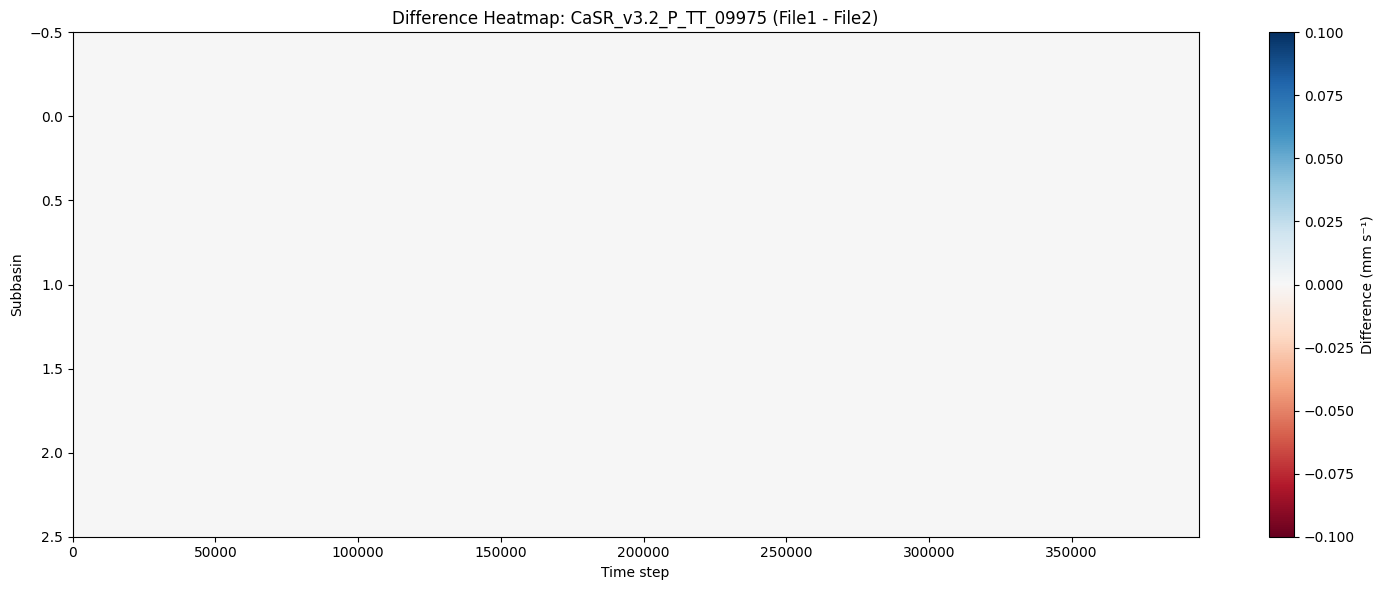

In [12]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------
# File paths
# ------------------------------
file1 = '/scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/MESH_forcing_cal_camels_casr3p2_1979_2024.nc'
file2 = '/scratch/zelalem/CanTrans-models/Calibration/GroupCalibration/group_8/xxMESH_forcing_cal_camels_casr3p2_1979_2024.nc'

# ------------------------------
# Open datasets
# ------------------------------
ds1 = xr.open_dataset(file1)
ds2 = xr.open_dataset(file2)

# ------------------------------
# Check dimensions
# ------------------------------
if not np.array_equal(ds1['time'], ds2['time']):
    print("Warning: Time dimensions differ between files")
if not np.array_equal(ds1['subbasin'], ds2['subbasin']):
    print("Warning: Subbasin dimensions differ between files")

# ------------------------------
# Load variable and mask fill values
# ------------------------------
var_name = 'CaSR_v3.2_P_TT_09975'
data1 = ds1[var_name].where(ds1[var_name] != -9999)
data2 = ds2[var_name].where(ds2[var_name] != -9999)

# ------------------------------
# Compute difference
# ------------------------------
diff = data1 - data2

# ------------------------------
# Summary statistics per subbasin
# ------------------------------
mean_diff_per_subbasin = diff.mean(dim='time')
max_diff_per_subbasin = diff.max(dim='time')
rmse_per_subbasin = np.sqrt((diff ** 2).mean(dim='time'))

#mean_diff_per_subbasin = diff.mean(dim='subbasin')
#max_diff_per_subbasin = diff.max(dim='subbasin')
#rmse_per_subbasin = np.sqrt((diff ** 2).mean(dim='subbasin'))

# ------------------------------
# Print overall summary
# ------------------------------
print("Overall difference statistics:")
print(f"Mean difference (all subbasins and times): {diff.mean().item():.6f}")
print(f"Max difference: {diff.max().item():.6f}")
print(f"Min difference: {diff.min().item():.6f}")
print(f"RMSE: {np.sqrt((diff**2).mean()).item():.6f}")

# ------------------------------
# Plot heatmap of differences
# ------------------------------
plt.figure(figsize=(15, 6))
plt.imshow(diff.T, aspect='auto', cmap='RdBu', vmin=-np.nanmax(np.abs(diff)), vmax=np.nanmax(np.abs(diff)))
plt.colorbar(label='Difference (mm s⁻¹)')
plt.xlabel('Time step')
plt.ylabel('Subbasin')
plt.title(f'Difference Heatmap: {var_name} (File1 - File2)')
plt.tight_layout()
plt.show()

In [ ]:
## Diagnostic Script to Compare Two NetCDF Files
## and detect ordering / coordinate problems

import xarray as xr
import numpy as np

def diagnose_netcdf_difference(
    expected_nc,
    produced_nc,
    dim_name="subbasin",
    variable_name=None,
    ncheck=20
):
    """
    Compare two NetCDF files and diagnose:
    - dimension sizes
    - coordinate ordering
    - variable ordering
    - data mismatches
    - positional vs coordinate alignment issues
    """

    print("\n========================================")
    print("OPENING FILES")
    print("========================================")

    ds_expected = xr.open_dataset(expected_nc)
    ds_produced = xr.open_dataset(produced_nc)

    print(f"\nExpected file : {expected_nc}")
    print(f"Produced file : {produced_nc}")

    # --------------------------------------------------
    # Dataset summary
    # --------------------------------------------------
    print("\n========================================")
    print("DATASET SUMMARY")
    print("========================================")

    print("\nEXPECTED DIMS:")
    print(ds_expected.dims)

    print("\nPRODUCED DIMS:")
    print(ds_produced.dims)

    # --------------------------------------------------
    # Coordinate check
    # --------------------------------------------------
    print("\n========================================")
    print("DIMENSION COORDINATE CHECK")
    print("========================================")

    coord_expected = ds_expected.indexes[dim_name].values
    coord_produced = ds_produced.indexes[dim_name].values

    print(f"\nFirst {ncheck} expected coordinates:")
    print(coord_expected[:ncheck])

    print(f"\nFirst {ncheck} produced coordinates:")
    print(coord_produced[:ncheck])

    # Exact coordinate comparison
    same_coords = np.array_equal(coord_expected, coord_produced)

    print(f"\nCoordinates identical? -> {same_coords}")

    if not same_coords:

        print("\nFirst differing positions:")

        mismatch = np.where(coord_expected != coord_produced)[0]

        for i in mismatch[:20]:
            print(
                f"Index {i}: "
                f"expected={coord_expected[i]} "
                f"produced={coord_produced[i]}"
            )

    # --------------------------------------------------
    # Variable selection
    # --------------------------------------------------
    if variable_name is None:

        candidate_vars = []

        for v in ds_expected.data_vars:
            if dim_name in ds_expected[v].dims:
                candidate_vars.append(v)

        if len(candidate_vars) == 0:
            raise ValueError(
                f"No variable found using dimension '{dim_name}'"
            )

        variable_name = candidate_vars[0]

    print("\n========================================")
    print("VARIABLE CHECK")
    print("========================================")

    print(f"\nUsing variable: {variable_name}")

    var_expected = ds_expected[variable_name]
    var_produced = ds_produced[variable_name]

    print("\nExpected variable dims:")
    print(var_expected.dims)

    print("\nProduced variable dims:")
    print(var_produced.dims)

    print("\nExpected shape:")
    print(var_expected.shape)

    print("\nProduced shape:")
    print(var_produced.shape)

    # --------------------------------------------------
    # POSITIONAL comparison
    # --------------------------------------------------
    print("\n========================================")
    print("POSITIONAL DATA COMPARISON")
    print("========================================")

    arr_expected = var_expected.values
    arr_produced = var_produced.values

    # Shape check
    if arr_expected.shape != arr_produced.shape:

        print("\nERROR:")
        print("Variable shapes differ.")
        print(arr_expected.shape, arr_produced.shape)

        return

    # Difference
    diff = arr_expected - arr_produced

    print(f"\nMean difference : {np.nanmean(diff):.6f}")
    print(f"Max difference  : {np.nanmax(diff):.6f}")
    print(f"Min difference  : {np.nanmin(diff):.6f}")
    print(f"RMSE            : {np.sqrt(np.nanmean(diff**2)):.6f}")

    # --------------------------------------------------
    # Spot-check values
    # --------------------------------------------------
    print("\n========================================")
    print("SPOT CHECK")
    print("========================================")

    if arr_expected.ndim == 1:

        for i in range(min(ncheck, len(arr_expected))):

            print(
                f"Index {i}: "
                f"expected={arr_expected[i]} "
                f"produced={arr_produced[i]}"
            )

    elif arr_expected.ndim >= 2:

        for i in range(min(ncheck, arr_expected.shape[0])):

            print(
                f"Index {i}: "
                f"expected={arr_expected[i,0]} "
                f"produced={arr_produced[i,0]}"
            )

    # --------------------------------------------------
    # Coordinate-alignment test
    # --------------------------------------------------
    print("\n========================================")
    print("XARRAY ALIGNMENT TEST")
    print("========================================")

    try:

        aligned_diff = var_expected - var_produced

        print("\nAlignment subtraction SUCCESS")

        print("Aligned shape:")
        print(aligned_diff.shape)

    except Exception as e:

        print("\nAlignment subtraction FAILED")

        print(str(e))

    # --------------------------------------------------
    # Missing coordinate check
    # --------------------------------------------------
    print("\n========================================")
    print("MISSING COORDINATE CHECK")
    print("========================================")

    missing_in_produced = np.setdiff1d(
        coord_expected,
        coord_produced
    )

    missing_in_expected = np.setdiff1d(
        coord_produced,
        coord_expected
    )

    print("\nCoordinates missing in produced:")
    print(missing_in_produced[:20])

    print("\nCoordinates missing in expected:")
    print(missing_in_expected[:20])

    print("\n========================================")
    print("DIAGNOSIS COMPLETE")
    print("========================================")

In [ ]:
diagnose_netcdf_difference(
    file2,
    file1,
    dim_name="subbasin",
    variable_name=None,
    ncheck=20
)

In [ ]:
ddb = xr.open_dataset(output_ddb_nc)
mask = ddb[["subbasin", "Rank", "Rank_old"]].to_dataframe().reset_index()
print(mask.head())

tcf = xr.open_dataset(output_forcing_nc)
target = tcf[["subbasin", "CaSR_v3.2_P_TT_09975"]].to_dataframe().reset_index()
target["Rank"] = target["subbasin"] + 1
target = target.merge(
    mask[["Rank", "subbasin", "Rank_old"]],
    on="Rank",
    how="inner"   # options: inner, left, right, outer
)
print(target.head())

scf = xr.open_dataset(input_forcing_nc)
source = scf[["subbasin", "CaSR_v3.2_P_TT_09975"]].to_dataframe().reset_index()
source["Rank"] = source["subbasin"] + 1
print(source.head())

target = target.merge(
    source[["subbasin", "Rank", "CaSR_v3.2_P_TT_09975"]],
    left_on="Rank_old",
    right_on="Rank",
    how="inner"   # options: inner, left, right, outer
)
print(target.head())

max_diff = (target["CaSR_v3.2_P_TT_09975_x"] - target["CaSR_v3.2_P_TT_09975_y"]).max()
print(max_diff)
min_diff = (target["CaSR_v3.2_P_TT_09975_x"] - target["CaSR_v3.2_P_TT_09975_y"]).min()
print(min_diff)

In [ ]:
import xarray as xr
import numpy as np

def subset_netcdf_climate_and_parameters(
    input_ddb_path,
    input_nc_path,
    output_nc_path,
    data_dim_name="subbasin",
    key_column="Rank_old"
):
    """
    Subset and reorder a NetCDF file using Rank_old.

    IMPORTANT
    ---------
    Rank_old in the masker file represents:

        ORIGINAL source NetCDF positional index + 1

    Example:
        Rank_old = 1  -> first subbasin in source file
        Rank_old = 232 -> 232nd subbasin in source file

    The output NetCDF:
    - extracts data in the exact masker order
    - resets subbasin coordinates to sequential order:
          1, 2, 3, ...
    """

    # -----------------------------------------
    # Open datasets
    # -----------------------------------------
    with xr.open_dataset(input_nc_path, chunks={"time": 100000}) as data_nc, \
         xr.open_dataset(input_ddb_path) as mask_nc:

        # -----------------------------------------
        # Read Rank_old from masker
        # -----------------------------------------
        rank_old = mask_nc[key_column].values.astype(int)

        # -----------------------------------------
        # Keep valid entries only
        # -----------------------------------------
        valid_mask = rank_old > 0

        rank_old_valid = rank_old[valid_mask]

        # -----------------------------------------
        # Convert to zero-based positional indices
        # because Rank_old = original index + 1
        # -----------------------------------------
        source_indices = rank_old_valid - 1

        # -----------------------------------------
        # Subset in EXACT masker order
        # -----------------------------------------
        subset = data_nc.isel(
            {data_dim_name: source_indices}
        )

        # -----------------------------------------
        # Reset subbasin coordinate
        # to sequential numbering
        # -----------------------------------------
        subset = subset.assign_coords(
            {
                data_dim_name: np.arange(
                    1,
                    len(source_indices) + 1,
                    dtype=int
                )
            }
        )

        # -----------------------------------------
        # Save output
        # -----------------------------------------
        subset.to_netcdf(output_nc_path)

    print(f"\nSubset NetCDF saved to:\n{output_nc_path}")

In [ ]:
def add_outlier_inset(ax, vals, ecdf_y, xlim_lo=-1.0):
    """Add an inset scatter plot showing eCDF outliers below *xlim_lo*.

    Clips the main axis to [xlim_lo, 1] and draws a small inset in the
    top-left (below the legend) with the outlier points as individual dots.
    """
    ax.set_xlim(xlim_lo, 1)
    outlier_mask = vals < xlim_lo
    if not outlier_mask.any():
        return
    ox = vals[outlier_mask]
    oy = ecdf_y[outlier_mask]
    inset = ax.inset_axes([0.08, 0.55, 0.30, 0.32])  # top-left, below legend
    inset.scatter(ox, oy, s=18, color=ax.get_lines()[0].get_color(),
                  edgecolors="k", linewidths=0.4, zorder=3)
    inset.set_xlim(ox.min() - 0.5, xlim_lo)
    inset.set_xticks(list(inset.get_xticks()) + [xlim_lo])
    inset.set_xlim(ox.min() - 0.5, xlim_lo)  # restore after set_xticks
    inset.set_ylim(-0.02, oy.max() + 0.05)
    inset.set_title(f"{len(ox)} outlier(s)", fontsize=7, pad=2)
    inset.tick_params(labelsize=6)
    inset.grid(True, alpha=0.3)




    # Individual eCDF per metric
    for col in metric_cols:
        vals = np.sort(df_metrics[col].dropna().values)
        ecdf_y = np.arange(1, len(vals) + 1) / len(vals)

        fig, ax = plt.subplots(figsize=(6, 5))
        ax.step(vals, ecdf_y, where="post", color="steelblue", lw=1.5)
        ax.set_xlabel(metric_labels[col], fontsize=12)
        ax.set_ylabel("eCDF", fontsize=12)
        ax.set_title(f"eCDF of {metric_labels[col]} — {len(vals)} stations", fontsize=12)
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)

        # Mark median
        med = np.median(vals)
        ax.axvline(med, color="red", ls="--", lw=0.8, label=f"median = {med:.3f}")
        if col == "KGE_2012_prime":
            mn = np.mean(vals)
            ax.axvline(mn, color="blue", ls=":", lw=0.8, label=f"mean = {mn:.3f}")

        # Focus KGE/NSE plots on [-1, 1] with outlier inset; legend bottom-right
        if col in ("KGE_2012", "KGE_2009", "NSE"):
            ax.legend(loc="lower right", fontsize=9)
            add_outlier_inset(ax, vals, ecdf_y)
        else:
            ax.legend(fontsize=9)

        fig.tight_layout()
        fig.savefig(os.path.join(out_base, f"eCDF_{col}.png"), dpi=150)
        plt.close(fig)

    # Combined eCDF (all metrics in one figure)
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    colors = ["steelblue", "teal", "darkorange", "seagreen", "crimson"]
    for ax, col, clr in zip(axes.flat, metric_cols, colors):
        vals = np.sort(df_metrics[col].dropna().values)
        ecdf_y = np.arange(1, len(vals) + 1) / len(vals)

        ax.step(vals, ecdf_y, where="post", color=clr, lw=1.5)
        ax.set_xlabel(metric_labels[col], fontsize=11)
        ax.set_ylabel("eCDF", fontsize=11)
        ax.set_title(metric_labels[col], fontsize=12)
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)
        med = np.median(vals)
        ax.axvline(med, color="red", ls="--", lw=0.8, label=f"median = {med:.3f}")
        if col == "KGE_2012_prime":
            mn = np.mean(vals)
            ax.axvline(mn, color="blue", ls=":", lw=0.8, label=f"mean = {mn:.3f}")
        if col in ("KGE_2012", "KGE_2009", "NSE"):
            ax.legend(loc="lower right", fontsize=9)
            add_outlier_inset(ax, vals, ecdf_y)
        else:
            ax.legend(fontsize=9)

    # Hide unused subplot (6th in 2x3 grid)
    axes.flat[5].set_visible(False)

    fig.suptitle(f"Performance Metrics — {exp_name} (n={len(df_metrics)} stations)",
                 fontsize=14, y=1.01)
    fig.tight_layout()
    fig.savefig(os.path.join(out_base, "eCDF_combined.png"), dpi=150,
                bbox_inches="tight")
    plt.close(fig)

    print(f"\neCDF plots saved to: {out_base}/")


    # Rows 1-2: eCDF plots (5 metrics in 2x3 grid, last cell empty)
    for i, (col, clr) in enumerate(zip(metric_cols, colors)):
        row = 1 + i // 3
        col_idx = i % 3
        ax = fig_report.add_subplot(gs[row, col_idx])
        vals = np.sort(df_metrics[col].dropna().values)
        ecdf_y = np.arange(1, len(vals) + 1) / len(vals)
        ax.step(vals, ecdf_y, where="post", color=clr, lw=1.5)
        ax.set_xlabel(metric_labels[col], fontsize=11)
        ax.set_ylabel("eCDF", fontsize=11)
        ax.set_title(f"eCDF — {metric_labels[col]}", fontsize=12)
        ax.set_ylim(0, 1.02)
        ax.grid(True, alpha=0.3)
        med = np.median(vals)
        ax.axvline(med, color="red", ls="--", lw=0.8, label=f"median = {med:.3f}")
        if col == "KGE_2012_prime":
            mn = np.mean(vals)
            ax.axvline(mn, color="blue", ls=":", lw=0.8, label=f"mean = {mn:.3f}")
        if col in ("KGE_2012", "KGE_2009", "NSE"):
            ax.legend(loc="lower right", fontsize=9)
            add_outlier_inset(ax, vals, ecdf_y)
        else:
            ax.legend(fontsize=9)